# Inventory Optimization & Supply Chain Strategy

**Portfolio Project | Industrial Engineering + Management Analytics**

**Objective:** analyze product demand, identify inventory risks, and build practical reorder-point and safety-stock recommendations using Python.

### Dataset required
Download **UCI Online Retail II**:
https://archive.ics.uci.edu/dataset/502/online+retail+ii

Place `online_retail_II.xlsx` in the **same folder as this notebook**. If the filename differs, change `DATA_FILE` below.


## 1. Setup

In [20]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

print("Environment ready.")


Environment ready.


## 2. Load Data

In [21]:
DATA_FILE = Path("online_retail_II.xlsx")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"{DATA_FILE} not found. Download the UCI Online Retail II Excel file "
        "and place it next to this notebook."
    )

excel = pd.ExcelFile(DATA_FILE)
print("Available sheets:", excel.sheet_names)

raw = pd.concat(
    [pd.read_excel(DATA_FILE, sheet_name=s) for s in excel.sheet_names],
    ignore_index=True
)

print("Raw shape:", raw.shape)
display(raw.head())


Available sheets: ['Year 2009-2010', 'Year 2010-2011']
Raw shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


## 3. Clean & Prepare the Data

In [22]:
df = raw.copy()

df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

rename_map = {
    "invoice": "invoice_no",
    "stockcode": "stock_code",
    "invoicedate": "invoice_date",
    "price": "unit_price",
    "customer_id": "customer_id"
}
df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns}, inplace=True)

required = ["invoice_no", "stock_code", "quantity", "invoice_date", "unit_price"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")

df.dropna(subset=required, inplace=True)

# Remove cancelled invoices and invalid sales
df["invoice_no"] = df["invoice_no"].astype(str)
df = df[~df["invoice_no"].str.upper().str.startswith("C")]
df = df[(df["quantity"] > 0) & (df["unit_price"] > 0)].copy()

df["sales_value"] = df["quantity"] * df["unit_price"]
df["date"] = df["invoice_date"].dt.date
df["month"] = df["invoice_date"].dt.to_period("M").astype(str)

print(f"Clean rows: {len(df):,}")
print(f"Products: {df.stock_code.nunique():,}")
print(f"Date range: {df.invoice_date.min().date()} → {df.invoice_date.max().date()}")
display(df.head())


Clean rows: 1,041,670
Products: 4,917
Date range: 2009-12-01 → 2011-12-09


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,sales_value,date,month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,83.40,2009-12-01,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00,2009-12-01,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00,2009-12-01,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,100.80,2009-12-01,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,30.00,2009-12-01,2009-12


## 4. Business Overview

In [23]:
overview = pd.DataFrame({
    "Metric": [
        "Transactions", "Unique products", "Unique customers",
        "Units sold", "Total sales", "Average transaction value"
    ],
    "Value": [
        len(df),
        df.stock_code.nunique(),
        df.customer_id.nunique() if "customer_id" in df.columns else np.nan,
        df.quantity.sum(),
        df.sales_value.sum(),
        df.sales_value.mean()
    ]
})
display(overview)


,Metric,Value
0,Transactions,"1,041,670.00"
1,Unique products,"4,917.00"
2,Unique customers,"5,878.00"
3,Units sold,"11,420,305.00"
4,Total sales,"20,972,594.57"
5,Average transaction value,20.13


## 5. Demand Trend

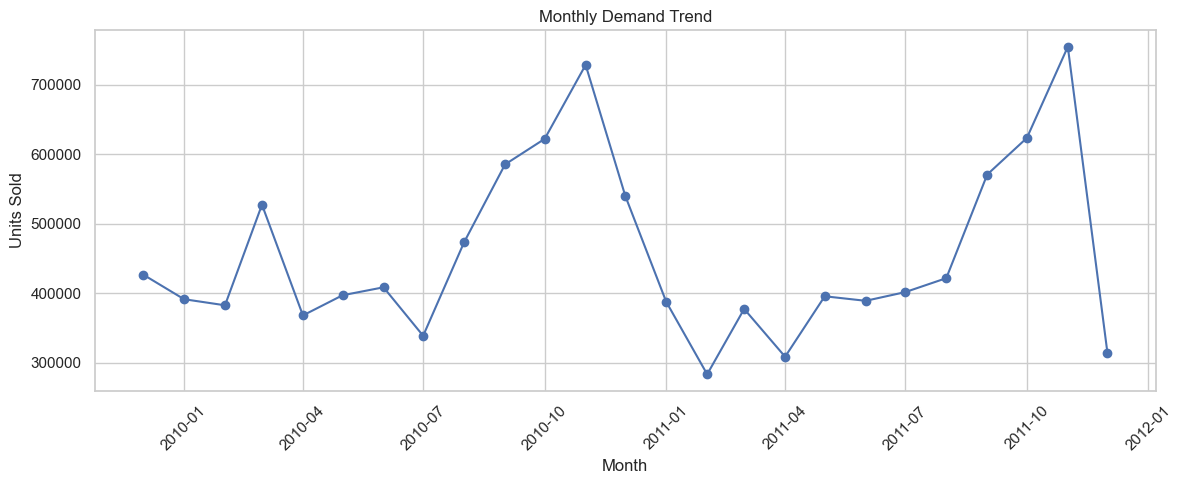

In [24]:
monthly = (
    df.groupby("month")
      .agg(
          units=("quantity", "sum"),
          sales=("sales_value", "sum"),
          transactions=("invoice_no", "nunique")
      )
      .reset_index()
)

monthly["month"] = pd.to_datetime(monthly["month"])

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly["month"], monthly["units"], marker="o")

ax.set_title("Monthly Demand Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Product Demand Analysis

,stock_code,units_sold,sales,transactions,avg_units_per_transaction
2963,84077,110138,"25,259.90",1019,108.08
4441,85099B,98349,"183,454.83",3989,24.66
490,21212,96560,"52,997.20",3118,30.97
4456,85123A,96147,"263,109.67",5365,17.92
1308,22197,89898,"80,920.64",2322,38.72
3132,84879,81809,"132,187.92",2807,29.14
2673,23843,80995,"168,469.60",1,"80,995.00"
2228,23166,78033,"81,700.92",247,315.92
50,17003,71430,"14,959.19",456,156.64
1121,21977,56794,"28,490.98",1993,28.50


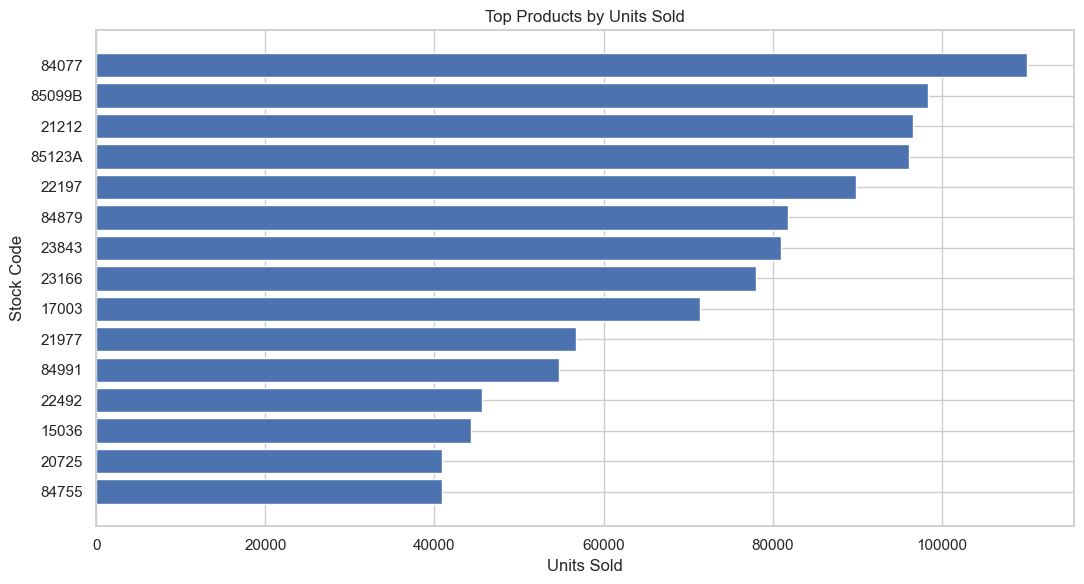

In [25]:
product_demand = (
    df.groupby("stock_code")
      .agg(
          units_sold=("quantity", "sum"),
          sales=("sales_value", "sum"),
          transactions=("invoice_no", "nunique")
      )
      .reset_index()
)

product_demand["avg_units_per_transaction"] = (
    product_demand["units_sold"] / product_demand["transactions"]
)

top_products = product_demand.sort_values(
    "units_sold", ascending=False
).head(15)

display(top_products)

plot_data = top_products.sort_values("units_sold")

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_data["stock_code"].astype(str),
    plot_data["units_sold"]
)

ax.set_title("Top Products by Units Sold")
ax.set_xlabel("Units Sold")
ax.set_ylabel("Stock Code")

plt.tight_layout()
plt.show()

## 7. Demand Variability

In [26]:
daily_product = (
    df.groupby(["stock_code","date"])["quantity"]
      .sum()
      .reset_index()
)

demand_stats = (
    daily_product.groupby("stock_code")["quantity"]
      .agg(average_daily_demand="mean",
           demand_std="std",
           demand_days="count")
      .reset_index()
)

demand_stats["cv"] = (
    demand_stats["demand_std"] /
    demand_stats["average_daily_demand"]
).replace([np.inf, -np.inf], np.nan)

product_analysis = product_demand.merge(demand_stats, on="stock_code", how="left")
display(product_analysis.sort_values("cv", ascending=False).head(15))


,stock_code,units_sold,sales,transactions,avg_units_per_transaction,average_daily_demand,demand_std,demand_days,cv
2228,23166,78033,"81,700.92",247,315.92,624.26,"6,635.41",125,10.63
177,20777,3669,"1,280.97",169,21.71,28.01,279.37,131,9.97
3396,15044A,4970,"13,228.55",250,19.88,26.30,255.11,189,9.70
174,20774,3493,977.33,119,29.35,36.39,326.30,96,8.97
173,20773,3357,993.68,117,28.69,34.61,308.96,97,8.93
175,20775,3611,939.80,112,32.24,40.12,353.89,90,8.82
155,20755,5162,"1,105.80",122,42.31,53.22,438.43,97,8.24
178,20778,3616,952.61,90,40.18,48.21,387.60,75,8.04
1126,21984,25509,"7,077.05",432,59.05,83.64,671.91,305,8.03
158,20758,5441,967.02,95,57.27,72.55,553.95,75,7.64


## 8. Product Segmentation

,segment,products,units_sold,sales,avg_cv
0,Fast Mover / Stable,788,6195544,"10,394,603.03",1.39
1,High-Risk / High-Demand,442,3343044,"5,139,032.98",3.15
2,Slow Mover / Stable,2944,1259239,"3,775,370.21",1.06
3,Slow Mover / Variable,743,622478,"1,663,588.35",2.83


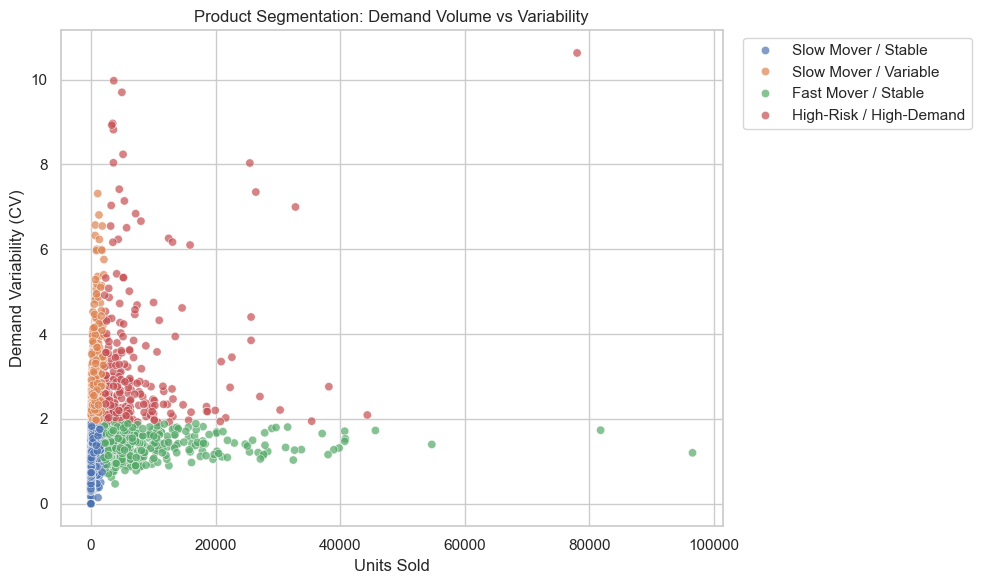

In [27]:
volume_threshold = product_analysis["units_sold"].quantile(0.75)
cv_threshold = product_analysis["cv"].quantile(0.75)

def segment(row):
    high_volume = row["units_sold"] >= volume_threshold
    high_variability = pd.notna(row["cv"]) and row["cv"] >= cv_threshold
    if high_volume and high_variability:
        return "High-Risk / High-Demand"
    if high_volume:
        return "Fast Mover / Stable"
    if high_variability:
        return "Slow Mover / Variable"
    return "Slow Mover / Stable"

product_analysis["segment"] = product_analysis.apply(segment, axis=1)

segment_summary = (
    product_analysis.groupby("segment")
      .agg(products=("stock_code","nunique"),
           units_sold=("units_sold","sum"),
           sales=("sales","sum"),
           avg_cv=("cv","mean"))
      .reset_index()
      .sort_values("sales", ascending=False)
)
display(segment_summary)

sample = product_analysis.sample(min(3000, len(product_analysis)), random_state=42)
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=sample, x="units_sold", y="cv", hue="segment", alpha=.7, ax=ax)
ax.set_title("Product Segmentation: Demand Volume vs Variability")
ax.set_xlabel("Units Sold")
ax.set_ylabel("Demand Variability (CV)")
ax.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


## 9. Inventory Policy Assumptions

In [28]:
LEAD_TIME_DAYS = 14
SERVICE_LEVEL_Z = 1.65       # approximately 95% service level
REVIEW_PERIOD_DAYS = 7

print("Lead time:", LEAD_TIME_DAYS, "days")
print("Target service level: approximately 95%")
print("Review period:", REVIEW_PERIOD_DAYS, "days")


Lead time: 14 days
Target service level: approximately 95%
Review period: 7 days


## 10. Safety Stock & Reorder Point

In [29]:
policy = product_analysis.copy()

policy["daily_demand_std"] = policy["demand_std"].fillna(0)

policy["safety_stock"] = (
    SERVICE_LEVEL_Z *
    policy["daily_demand_std"] *
    np.sqrt(LEAD_TIME_DAYS)
)

policy["reorder_point"] = (
    policy["average_daily_demand"] * LEAD_TIME_DAYS
    + policy["safety_stock"]
)

policy["cycle_stock"] = policy["average_daily_demand"] * REVIEW_PERIOD_DAYS

policy["recommended_inventory"] = (
    policy["reorder_point"] + policy["cycle_stock"]
)

display(
    policy[[
        "stock_code","units_sold","average_daily_demand","cv",
        "safety_stock","reorder_point","recommended_inventory","segment"
    ]].sort_values("units_sold", ascending=False).head(20)
)


,stock_code,units_sold,average_daily_demand,cv,safety_stock,reorder_point,recommended_inventory,segment
2963,84077,110138,234.34,2.25,"3,258.66","6,539.36","8,179.71",High-Risk / High-Demand
4441,85099B,98349,166.98,1.12,"1,157.25","3,494.92","4,663.75",Fast Mover / Stable
490,21212,96560,162.56,1.20,"1,204.45","3,480.28","4,618.19",Fast Mover / Stable
4456,85123A,96147,159.45,1.37,"1,350.16","3,582.43","4,698.56",Fast Mover / Stable
1308,22197,89898,159.68,2.23,"2,202.61","4,438.08","5,555.82",High-Risk / High-Demand
3132,84879,81809,140.57,1.73,"1,504.32","3,472.23","4,456.19",Fast Mover / Stable
2673,23843,80995,"80,995.00",NaN,0.00,"1,133,930.00","1,700,895.00",Fast Mover / Stable
2228,23166,78033,624.26,10.63,"40,965.23","49,704.93","54,074.78",High-Risk / High-Demand
50,17003,71430,237.31,3.51,"5,146.10","8,468.43","10,129.59",High-Risk / High-Demand
1121,21977,56794,100.52,1.78,"1,107.02","2,514.31","3,217.95",Fast Mover / Stable


## 11. Inventory Risk Prioritization

In [30]:
risk = policy.copy()

demand_cutoff = risk["units_sold"].quantile(.50)

risk["priority"] = np.select(
    [
        (risk["units_sold"] >= demand_cutoff) & (risk["cv"] >= cv_threshold),
        risk["units_sold"] >= demand_cutoff,
        (risk["units_sold"] < demand_cutoff) & (risk["cv"] >= cv_threshold)
    ],
    [
        "Urgent: High Demand + High Variability",
        "Monitor: High Demand",
        "Review: Variable Low Demand"
    ],
    default="Low Priority"
)

priority_summary = (
    risk.groupby("priority")
      .agg(products=("stock_code","nunique"),
           units_sold=("units_sold","sum"),
           sales=("sales","sum"))
      .reset_index()
      .sort_values("sales", ascending=False)
)

display(priority_summary)


,priority,products,units_sold,sales
1,Monitor: High Demand,1585,7157906,"12,947,236.81"
3,Urgent: High Demand + High Variability,874,3861736,"6,400,289.86"
0,Low Priority,2147,296877,"1,222,736.43"
2,Review: Variable Low Demand,311,103786,"402,331.47"


## 12. Management Action Table

In [31]:
action_table = (
    risk[[
        "stock_code","units_sold","sales","cv",
        "safety_stock","reorder_point",
        "recommended_inventory","segment","priority"
    ]]
    .sort_values(["priority","sales"], ascending=[True,False])
)

display(action_table.head(30))


,stock_code,units_sold,sales,cv,safety_stock,reorder_point,recommended_inventory,segment,priority
4880,AMAZONFEE,4,"34,009.13",0.43,3.56,22.23,31.56,Slow Mover / Stable,Low Priority
4883,C2,273,"13,676.00",0.48,4.16,23.66,33.41,Slow Mover / Stable,Low Priority
1734,22655,77,"13,140.00",0.55,5.83,29.79,41.76,Slow Mover / Stable,Low Priority
4881,B,1,"11,062.06",NaN,0.00,14.00,21.00,Slow Mover / Stable,Low Priority
1735,22656,45,"9,290.00",0.51,4.32,23.41,32.95,Slow Mover / Stable,Low Priority
4878,ADJUST,36,"8,897.93",NaN,0.00,504.00,756.00,Slow Mover / Stable,Low Priority
1589,22504,374,"8,224.63",1.28,33.52,93.02,122.77,Slow Mover / Stable,Low Priority
2078,23007,499,"7,758.70",1.40,33.40,87.56,114.63,Slow Mover / Stable,Low Priority
616,21361,587,"7,750.07",1.34,25.12,67.48,88.66,Slow Mover / Stable,Low Priority
1902,22827,49,"7,605.00",0.56,5.47,27.60,38.66,Slow Mover / Stable,Low Priority


## 13. Recommended Inventory Coverage

In [32]:
risk["recommended_days_of_supply"] = (
    risk["recommended_inventory"] /
    risk["average_daily_demand"].replace(0, np.nan)
)

coverage = pd.DataFrame({
    "Metric": [
        "Average recommended days of supply",
        "Median recommended days of supply",
        "Products >60 days of supply",
        "Products >90 days of supply"
    ],
    "Value": [
        risk["recommended_days_of_supply"].mean(),
        risk["recommended_days_of_supply"].median(),
        (risk["recommended_days_of_supply"] > 60).sum(),
        (risk["recommended_days_of_supply"] > 90).sum()
    ]
})
display(coverage)


,Metric,Value
0,Average recommended days of supply,30.44
1,Median recommended days of supply,29.12
2,Products >60 days of supply,33.00
3,Products >90 days of supply,0.00


## 14. Executive Recommendations

In [33]:
urgent_count = (
    risk["priority"] == "Urgent: High Demand + High Variability"
).sum()

print("EXECUTIVE RECOMMENDATIONS")
print("-" * 55)
print("1. Prioritize high-demand products with high demand variability.")
print("2. Protect important products with safety stock.")
print("3. Use reorder points based on demand and supplier lead time.")
print("4. Review slow-moving products to reduce unnecessary inventory.")
print("5. Recalculate policies periodically as demand changes.")
print(f"6. Urgent-priority products identified: {urgent_count:,}")


EXECUTIVE RECOMMENDATIONS
-------------------------------------------------------
1. Prioritize high-demand products with high demand variability.
2. Protect important products with safety stock.
3. Use reorder points based on demand and supplier lead time.
4. Review slow-moving products to reduce unnecessary inventory.
5. Recalculate policies periodically as demand changes.
6. Urgent-priority products identified: 874


## 15. Final Business Takeaways

### Skills demonstrated
- Demand analytics
- Supply chain analytics
- Inventory management
- Safety-stock calculation
- Reorder-point design
- Risk prioritization
- Management recommendations

### CV project title
**Inventory Optimization & Supply Chain Strategy**

**Keywords:** Supply Chain Analytics · Inventory Optimization · Operations Management · Demand Analysis · Safety Stock · Reorder Point · Decision Analytics · Python · Industrial Engineering

> **Model limitation:** the dataset does not contain actual warehouse inventory balances. Therefore, this notebook develops a **recommended inventory policy scenario** rather than claiming to measure actual stock levels or realized savings.
